### Performance envaluation benchmarks
Creating an instace of the PPI Generation+Analysis+Visualization app and evaluating latency on each pipeline stage 
- Generation (LLM prompt+response)
- Parsing (parsing LLM output)
- Analysis (STRING validation, GO Resnik Semantic Similarity, D-SCRIPT)

Analysis stage is further assessed based on baseline (non-parallel) execution and parallelized execution

In [20]:
import sys
import os
import importlib

current_dir = os.getcwd()
src_path = os.path.abspath(os.path.join(current_dir, '..'))

if src_path not in sys.path:
    sys.path.insert(0, src_path)

if 'visg.main_app' in sys.modules:
    from visg.main_app import app
    app.view_functions.clear()

import visg.main_app
importlib.reload(visg.main_app)
from visg.main_app import app

print("App reloaded. Current working directory:", os.getcwd())

def setup_benchmark():
    with app.test_client() as client:
        client.post('/build_go_dag', json={'go_file': 'go-basic.obo'})
        client.post('/build_ic', json={'gaf_file': 'goa_human.gaf'})
        print("System Ready.\n")

App reloaded. Current working directory: /Users/allison/Documents/GitHub/llm-protein-graph-vis/src/visg


### Setting up system 
Loading GO directed acyclic graph (DAG), information content (IC) lookup table for GO-BP calculations

In [21]:
setup_benchmark()

Building GO DAG...
/Users/allison/Documents/GitHub/llm-protein-graph-vis/src/visg/static/data/go-data/go-basic.obo: fmt(1.2) rel(2025-07-22) 43,230 Terms
Building IC lookup table...
HMS:0:00:10.546764 993,392 annotations READ: /Users/allison/Documents/GitHub/llm-protein-graph-vis/src/visg/static/data/go-data/goa_human.gaf 
Successfully loaded terms across BP, MF, and CC.
System Ready.



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import json

def run_benchmark(protein_id='PDCD1', model='llama3.1', test_size=1, test_mode="parallel"):
    with app.test_client() as client:
        payload = {
            "protein_id": protein_id,
            "model": model,
            "test": True,
            "test_mode": test_mode,
            "test_size": test_size
        }

        print(f"Running benchmark for {protein_id}...")
        response = client.post('/api/predict', 
                                data=json.dumps(payload),
                                content_type='application/json')

        if response.status_code != 200:
            print(f"Error {response.status_code}: {response.get_data(as_text=True)}")
            return None

        data = response.get_json()
        stats = data.get('stats', {})
        n_count = stats.get('N_Nodes', len(data['nodes']))
        results = []
        a_results = []
        for stage in ['Generation', 'Parsing', 'Analysis']:
            results.append({
                'Protein': protein_id,
                'Nodes': n_count,
                'Time': stats.get(stage, 0),
                'Stage': stage,
                'Config': test_mode
            })
        for stage in ['Analysis_STRING', 'Analysis_Resnik', 'Analysis_DSCRIPT']:
            a_results.append({
                'Protein': protein_id,
                'Nodes': n_count,
                'Time': stats.get(stage, 0),
                'Stage': stage,
                'Config': test_mode
            })
        print(f"Finished benchmark for test size {test_size} in {stats.get('Total_Time', 0):.2f}s")
        return pd.DataFrame(results), pd.DataFrame(a_results)

### Parallelized pipeline tests

In [101]:
result_1, result_1a = run_benchmark(protein_id='PDCD1', test_size=1, test_mode='parallel')
result_5, result_5a = run_benchmark(protein_id='PDCD1', test_size=5, test_mode='parallel')
result_10, result_10a = run_benchmark(protein_id='PDCD1', test_size=10, test_mode='parallel')
result_20, result_20a = run_benchmark(protein_id='PDCD1', test_size=20, test_mode='parallel')
df_bench = pd.concat([result_1, result_5, result_10, result_20])

Running benchmark for PDCD1...
TEST MODE: Scaled id_map to exactly 1 nodes for benchmarking.
Predicting: PDCD1 (288aa) x LY9 (655aa)

Finished benchmark for test size 1 in 5.87s
Running benchmark for PDCD1...
TEST MODE: Scaled id_map to exactly 5 nodes for benchmarking.
Predicting: PDCD1 (288aa) x CD28 (220aa)

Predicting: PDCD1 (288aa) x CTLA4 (223aa)

Predicting: PDCD1 (288aa) x ICOS (199aa)

Predicting: PDCD1 (288aa) x ICOS (199aa)

Predicting: PDCD1 (288aa) x ICOS (199aa)

Finished benchmark for test size 5 in 11.84s
Running benchmark for PDCD1...
Skipping hallucination or invalid symbol: LAG
Skipping hallucination or invalid symbol: PD
TEST MODE: Scaled id_map to exactly 10 nodes for benchmarking.
Predicting: PDCD1 (288aa) x CD28 (220aa)

Predicting: PDCD1 (288aa) x CTLA4 (223aa)

Predicting: PDCD1 (288aa) x ICOS (199aa)

Predicting: PDCD1 (288aa) x ICOS (199aa)

Predicting: PDCD1 (288aa) x ICOS (199aa)

Predicting: PDCD1 (288aa) x ICOS (199aa)

Predicting: PDCD1 (288aa) x ICOS (1

### Baseline execution (no parallelization)

In [102]:
base_res_1, base_res_1a = run_benchmark(protein_id='PDCD1', test_size=1, test_mode='baseline')
base_res_5, base_res_5a = run_benchmark(protein_id='PDCD1', test_size=5, test_mode='baseline')
base_res_10, base_res_10a = run_benchmark(protein_id='PDCD1', test_size=10, test_mode='baseline')
base_res_20, base_res_20a = run_benchmark(protein_id='PDCD1', test_size=20, test_mode='baseline')
df_base = pd.concat([base_res_1, base_res_5, base_res_10, base_res_20])
df_base_a = pd.concat([base_res_1a, base_res_5a, base_res_10a, base_res_20a])

Running benchmark for PDCD1...
TEST MODE: Scaled id_map to exactly 1 nodes for benchmarking.
Predicting: PDCD1 (288aa) x FCGR2A (317aa)

Finished benchmark for test size 1 in 4.15s
Running benchmark for PDCD1...
TEST MODE: Scaled id_map to exactly 5 nodes for benchmarking.
Predicting: PDCD1 (288aa) x PIK3R1 (724aa)

Predicting: PDCD1 (288aa) x TNFRSF14 (283aa)

Predicting: PDCD1 (288aa) x LAG3 (525aa)

Predicting: PDCD1 (288aa) x CTLA4 (223aa)

Predicting: PDCD1 (288aa) x SIRPA (504aa)

Finished benchmark for test size 5 in 14.15s
Running benchmark for PDCD1...
Skipping hallucination or invalid symbol: SHIP1
TEST MODE: Scaled id_map to exactly 10 nodes for benchmarking.
Predicting: PDCD1 (288aa) x LAG3 (525aa)

Predicting: PDCD1 (288aa) x CTLA4 (223aa)

Predicting: PDCD1 (288aa) x ICOS (199aa)

Predicting: PDCD1 (288aa) x BTLA (289aa)

Predicting: PDCD1 (288aa) x CD28 (220aa)

Predicting: PDCD1 (288aa) x VAV1 (845aa)

Predicting: PDCD1 (288aa) x VAV1 (845aa)

Predicting: PDCD1 (288aa) 

In [105]:
df_base['Config'] = 'baseline'
df_base

,Protein,Nodes,Time,Stage,Config
0,PDCD1,1,1.429803,Generation,baseline
1,PDCD1,1,0.239122,Parsing,baseline
2,PDCD1,1,2.235415,Analysis,baseline
0,PDCD1,5,3.468243,Generation,baseline
1,PDCD1,5,1.789458,Parsing,baseline
2,PDCD1,5,8.609142,Analysis,baseline
0,PDCD1,10,5.938994,Generation,baseline
1,PDCD1,10,1.836724,Parsing,baseline
2,PDCD1,10,18.256534,Analysis,baseline
0,PDCD1,20,11.520544,Generation,baseline


In [107]:
df_bench['Config'] = 'parallel'
df_bench

,Protein,Nodes,Time,Stage,Config
0,PDCD1,1,2.828096,Generation,parallel
1,PDCD1,1,0.237746,Parsing,parallel
2,PDCD1,1,2.536914,Analysis,parallel
0,PDCD1,5,6.000630,Generation,parallel
1,PDCD1,5,0.746061,Parsing,parallel
2,PDCD1,5,4.860420,Analysis,parallel
0,PDCD1,10,7.246945,Generation,parallel
1,PDCD1,10,1.269722,Parsing,parallel
2,PDCD1,10,7.618401,Analysis,parallel
0,PDCD1,20,11.260332,Generation,parallel


### Plotting results

/var/folders/cf/4gvf1xvn2d5d2txbc84b_0880000gn/T/ipykernel_51575/2907002006.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha="right")


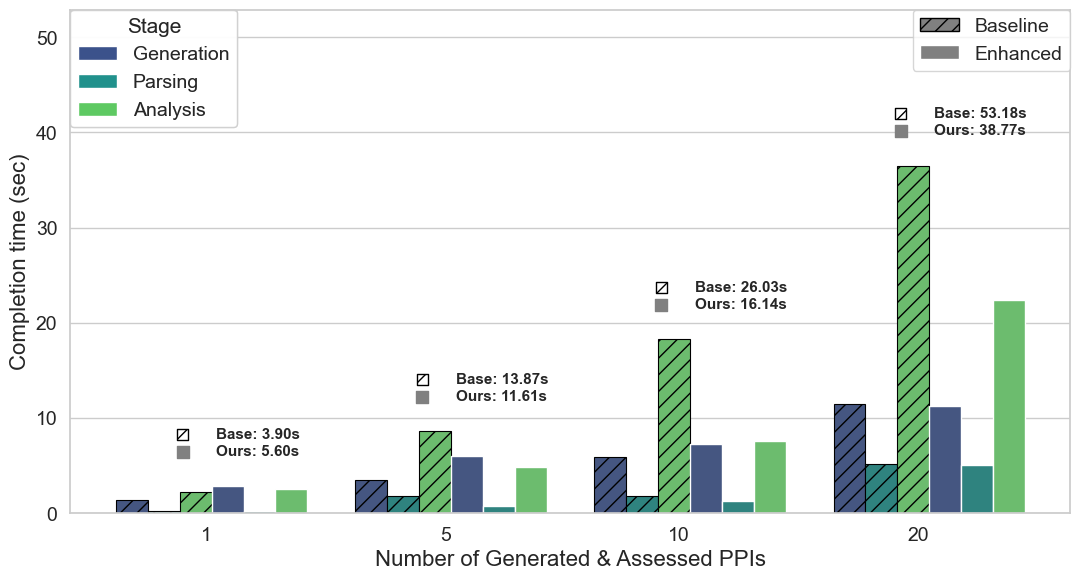

In [108]:
from matplotlib.patches import Patch

stage_labels = ['Generation', 'Parsing', 'Analysis']
# df_long = df_bench.copy()
df_long = pd.concat([df_bench, df_base])
df_long["stage_config"] = (
    df_long["Stage"] + " | " + df_long["Config"]
)
base_colors = sns.color_palette("viridis", n_colors=len(stage_labels))
stage_color_map = dict(zip(stage_labels, base_colors))

palette = {}
for stage in stage_labels:
    # palette[f"{stage}"] = stage_color_map[stage]
    palette[f"{stage} | baseline"] = stage_color_map[stage]
    palette[f"{stage} | parallel"]   = stage_color_map[stage]

hue_order = (
    # [f"{stage}" for stage in stage_labels]
    [f"{stage} | baseline" for stage in stage_labels] +
    [f"{stage} | parallel"   for stage in stage_labels]
)

totals = df_long.groupby(['Nodes', 'Config'])['Time'].sum().unstack('Config').reset_index()
totals.rename(columns={'baseline': 't_base', 'parallel': 't_opt'}, inplace=True)
node_values = sorted(df_long['Nodes'].unique())
xpos = {val: i for i, val in enumerate(node_values)}

ANNOT_FONTSIZE = 11
MARKER_SIZE = 8
global_ymax = df_long['Time'].max()

sns.set_theme(style="whitegrid", font_scale=1.1)

plt.rcParams.update({
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "legend.title_fontsize": 15,
})

fig, ax = plt.subplots(figsize=(11, 6))

sns.barplot(
    data=df_long, 
    x='Nodes', 
    y='Time', 
    hue='stage_config',
    hue_order=hue_order,
    palette=palette,
    dodge=True,
    errorbar=None,
    ax=ax
)

# Apply hatching to baseline bars
n_hue = len(hue_order)
n_baseline = len(stage_labels)          # 4
n_ticks = df_long["Nodes"].nunique()        # 8

for i, patch in enumerate(ax.patches):
    hue_idx = i // n_ticks              # which hue level this patch belongs to

    if hue_idx < n_baseline:           # cached hues are the second half
        patch.set_hatch("//")
        patch.set_edgecolor("black")
        patch.set_linewidth(0.8)
    else:
        patch.set_hatch("")

# annotations above each bar
# for container in ax.containers:
#     ax.bar_label(
#         container, 
#         fmt='%.2fs',       # Format to 2 decimal places with an 's'
#         padding=3,         # Space between top of bar and text
#         fontsize=10,       # Adjust based on your preference
#         fontweight='bold',
#         rotation=0         # Keep it horizontal
#     )

for _, row in totals.iterrows():
    N = row["Nodes"]
    x = xpos[N]
    
    # Find the peak of the current bar group to avoid overlap
    y_peak = df_long[df_long["Nodes"] == N]["Time"].max()
    y_base = y_peak + (global_ymax * 0.15)  # Baseline total
    y_opt  = y_peak + (global_ymax * 0.10)  # Enhanced total

    # --- Baseline: Hatched Square ---
    ax.scatter(
        x - 0.12, y_base,
        marker="s",
        s=MARKER_SIZE**2,
        facecolor="white",
        edgecolor="black",
        hatch="//",
        linewidth=1.0,
        zorder=10
    )
    ax.text(
        x + 0.02, y_base,
        f"Base: {row['t_base']:.2f}s",
        ha="left",
        va="center",
        fontsize=ANNOT_FONTSIZE,
        fontweight='bold'
    )

    # --- Enhanced: Solid Square ---
    ax.scatter(
        x - 0.12, y_opt,
        marker="s",
        s=MARKER_SIZE**2,
        color="gray",
        zorder=10
    )
    ax.text(
        x + 0.02, y_opt,
        f"Ours: {row['t_opt']:.2f}s",
        ha="left",
        va="center",
        fontsize=ANNOT_FONTSIZE,
        fontweight='bold',
    )

# Remove seaborn legend
ax.legend_.remove()

# Stage legend (colors)
stage_handles = [
    Patch(facecolor=stage_color_map[label], label=label)
    for label in stage_labels
]
leg1 = ax.legend(
    handles=stage_handles,
    title="Stage",
    loc="upper left",
    borderaxespad=0.0
)

ax.add_artist(leg1)

# Configuration legend (texture)
config_handles = [
    Patch(facecolor="gray",  hatch="//", edgecolor="black", label="Baseline"),
    Patch(facecolor="gray", label="Enhanced"),
]
ax.legend(
    handles=config_handles,
    loc="upper right",
    borderaxespad=0.0
)

ax.add_artist(leg1)
plt.xlabel('Number of Generated & Assessed PPIs')
plt.ylabel('Completion time (sec)')
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax * 1.2)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:g}")
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha="right")
plt.tight_layout()
plt.show()

In [110]:
totals

Config,Nodes,t_base,t_opt
0,1,3.904340,5.602756
1,5,13.866843,11.607111
2,10,26.032252,16.135068
3,20,53.179815,38.771175


/var/folders/cf/4gvf1xvn2d5d2txbc84b_0880000gn/T/ipykernel_51575/338277018.py:112: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha="right")


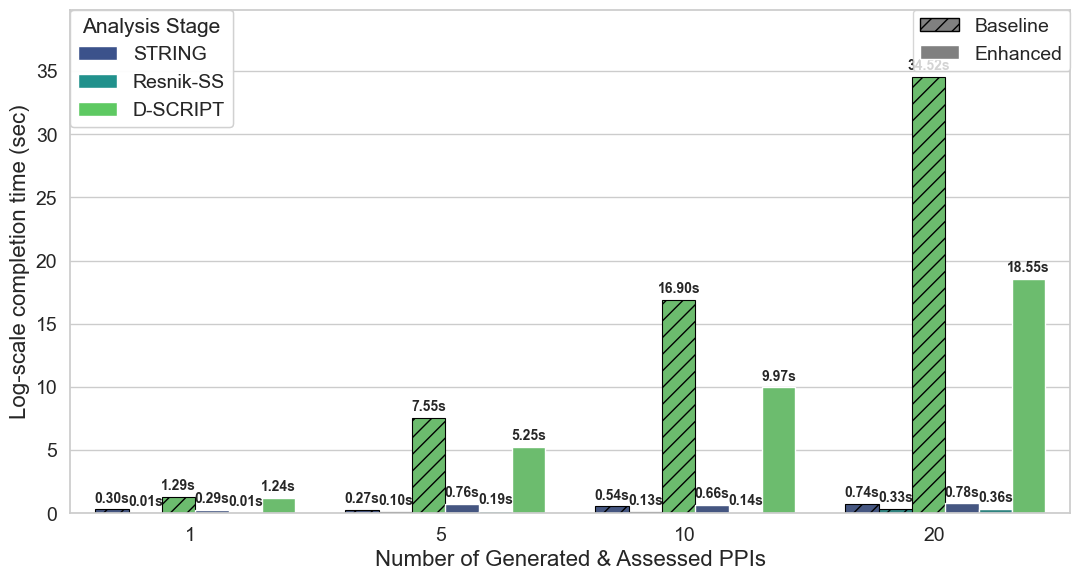

In [116]:
from matplotlib.patches import Patch

stage_labels = {"Analysis_STRING": "STRING", "Analysis_Resnik": "Resnik-SS", "Analysis_DSCRIPT": "D-SCRIPT"}
df_long = pd.concat([df_bench_a, df_base_a])
df_long["stage_label"] = df_long["Stage"].map(stage_labels)
df_long["stage_config"] = (
    df_long["stage_label"] + " | " + df_long["Config"]
)
base_colors = sns.color_palette("viridis", n_colors=len(stage_labels.values()))
stage_color_map = dict(zip(stage_labels.values(), base_colors))

palette = {}
for stage in stage_labels.values():
    # palette[f"{stage}"] = stage_color_map[stage]
    palette[f"{stage} | baseline"] = stage_color_map[stage]
    palette[f"{stage} | parallel"]   = stage_color_map[stage]

hue_order = (
    # [f"{stage}" for stage in stage_labels]
    [f"{stage} | baseline" for stage in stage_labels.values()] +
    [f"{stage} | parallel"   for stage in stage_labels.values()]
)

sns.set_theme(style="whitegrid", font_scale=1.1)

plt.rcParams.update({
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "legend.title_fontsize": 15,
})

fig, ax = plt.subplots(figsize=(11, 6))

sns.barplot(
    data=df_long, 
    x='Nodes', 
    y='Time', 
    hue='stage_config',
    hue_order=hue_order,
    palette=palette,
    dodge=True,
    errorbar=None,
    ax=ax
)

# Apply hatching to baseline bars
n_hue = len(hue_order)
n_baseline = len(stage_labels)          # 4
n_ticks = df_long["Nodes"].nunique()        # 8

for i, patch in enumerate(ax.patches):
    hue_idx = i // n_ticks              # which hue level this patch belongs to

    if hue_idx < n_baseline:           # cached hues are the second half
        patch.set_hatch("//")
        patch.set_edgecolor("black")
        patch.set_linewidth(0.8)
    else:
        patch.set_hatch("")

for container in ax.containers:
    ax.bar_label(
        container, 
        fmt='%.2fs',       # Format to 2 decimal places with an 's'
        padding=3,         # Space between top of bar and text
        fontsize=10,       # Adjust based on your preference
        fontweight='bold',
        rotation=0         # Keep it horizontal
    )

# Remove seaborn legend
ax.legend_.remove()

# Stage legend (colors)
stage_handles = [
    Patch(facecolor=stage_color_map[label], label=label)
    for label in stage_labels.values()
]
leg1 = ax.legend(
    handles=stage_handles,
    title="Analysis Stage",
    loc="upper left",
    borderaxespad=0.0
)

ax.add_artist(leg1)

# Configuration legend (texture)
config_handles = [
    Patch(facecolor="gray",  hatch="//", edgecolor="black", label="Baseline"),
    Patch(facecolor="gray", label="Enhanced"),
]
ax.legend(
    handles=config_handles,
    loc="upper right",
    borderaxespad=0.0
)


ax.add_artist(leg1)
plt.xlabel('Number of Generated & Assessed PPIs')
plt.ylabel('Log-scale completion time (sec)')
# ax.set_yscale("log")
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax * 1.1)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:g}")
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha="right")
plt.tight_layout()
plt.show()